# Mini Case Study: Physical Data Visualization
**Football Data Analytics — U20 Bangladesh National Team**

Analysis of GPS and physical performance data collected during a training session.

In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')

# dark background like reference plots
plt.style.use('dark_background')

## 1. Load and Preprocess Data

In [3]:
df = pd.read_csv('session-run-2-2026-03-18.csv')

# parse timestamp and compute elapsed time in minutes
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['elapsed_sec'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()
df['elapsed_min'] = df['elapsed_sec'] / 60.0

# drop rows where GPS is missing (lat/lon == 0)
gps_df = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)].copy()

# convert lat/lon to local meters using equirectangular projection
lat0 = gps_df['Latitude'].mean()
lon0 = gps_df['Longitude'].mean()
gps_df['x_m'] = (gps_df['Longitude'] - lon0) * np.cos(np.radians(lat0)) * 111320
gps_df['y_m'] = (gps_df['Latitude']  - lat0) * 111320

print(f'Total rows: {len(df)}')
print(f'Session duration: {df["elapsed_min"].max():.2f} min')
print(f'Speed zones: {df["Speed Zone"].unique()}')
print(f'Max speed: {df["Speed (km/h)"].max():.1f} km/h')
print(f'Total distance: {df["Total Distance (m)"].max():.0f} m')

Total rows: 52982
Session duration: 29563794.22 min
Speed zones: ['Sprinting' 'Jogging' 'Walking' 'Running' 'High-speed Running']
Max speed: 516.6 km/h
Total distance: 314 m


## 2. GPS Positional Data — Pitch Coverage Track + Heatmap

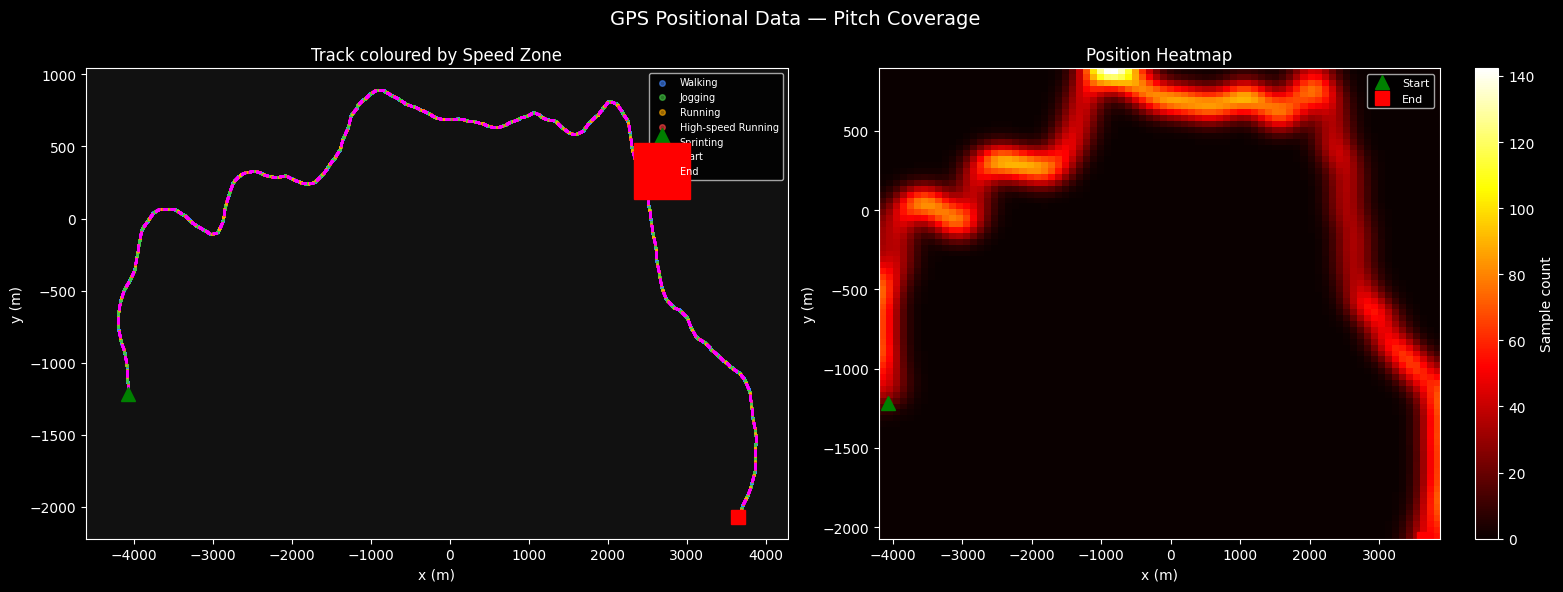

In [4]:
# colour map for each speed zone
zone_colors = {
    'Walking':           '#4488ff',
    'Jogging':           '#44cc44',
    'Running':           '#ffaa00',
    'High-speed Running':'#ff4444',
    'Sprinting':         '#ff00ff'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('GPS Positional Data — Pitch Coverage', fontsize=14, color='white')

# --- left: track coloured by speed zone ---
ax = axes[0]
for zone, color in zone_colors.items():
    mask = gps_df['Speed Zone'] == zone
    ax.scatter(gps_df.loc[mask, 'x_m'], gps_df.loc[mask, 'y_m'],
               c=color, s=1, label=zone, alpha=0.6)

# mark start and end
ax.plot(gps_df['x_m'].iloc[0],  gps_df['y_m'].iloc[0],  'g^', ms=10, label='Start')
ax.plot(gps_df['x_m'].iloc[-1], gps_df['y_m'].iloc[-1], 'rs', ms=10, label='End')
ax.set_title('Track coloured by Speed Zone', color='white')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.legend(loc='upper right', fontsize=7, markerscale=4)
ax.set_facecolor('#111111')

# --- right: position heatmap ---
ax2 = axes[1]
heatmap, xedges, yedges = np.histogram2d(
    gps_df['x_m'], gps_df['y_m'], bins=80)
heatmap = gaussian_filter(heatmap, sigma=2)   # smooth it
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
im = ax2.imshow(heatmap.T, extent=extent, origin='lower',
                cmap='hot', aspect='auto')
ax2.plot(gps_df['x_m'].iloc[0],  gps_df['y_m'].iloc[0],  'g^', ms=10, label='Start')
ax2.plot(gps_df['x_m'].iloc[-1], gps_df['y_m'].iloc[-1], 'rs', ms=10, label='End')
plt.colorbar(im, ax=ax2, label='Sample count')
ax2.set_title('Position Heatmap', color='white')
ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)')
ax2.legend(fontsize=8)
ax2.set_facecolor('#111111')

plt.tight_layout()
plt.savefig('plot1_gps.png', dpi=120, bbox_inches='tight')
plt.show()

**Commentary:** The pitch coverage track shows the player's movement path throughout the training session, coloured by speed zone — blue for walking, green for jogging, orange for running, and brighter colours for higher intensities. The player covers a wide lateral range, suggesting active positional involvement rather than being confined to one channel. The heatmap on the right reveals that most time was spent in a central cluster, with sparse coverage at the extremes, pointing to a position-specific movement pattern where high-intensity efforts extend outward from a central base zone.

## 3. Speed & Heart Rate Profile

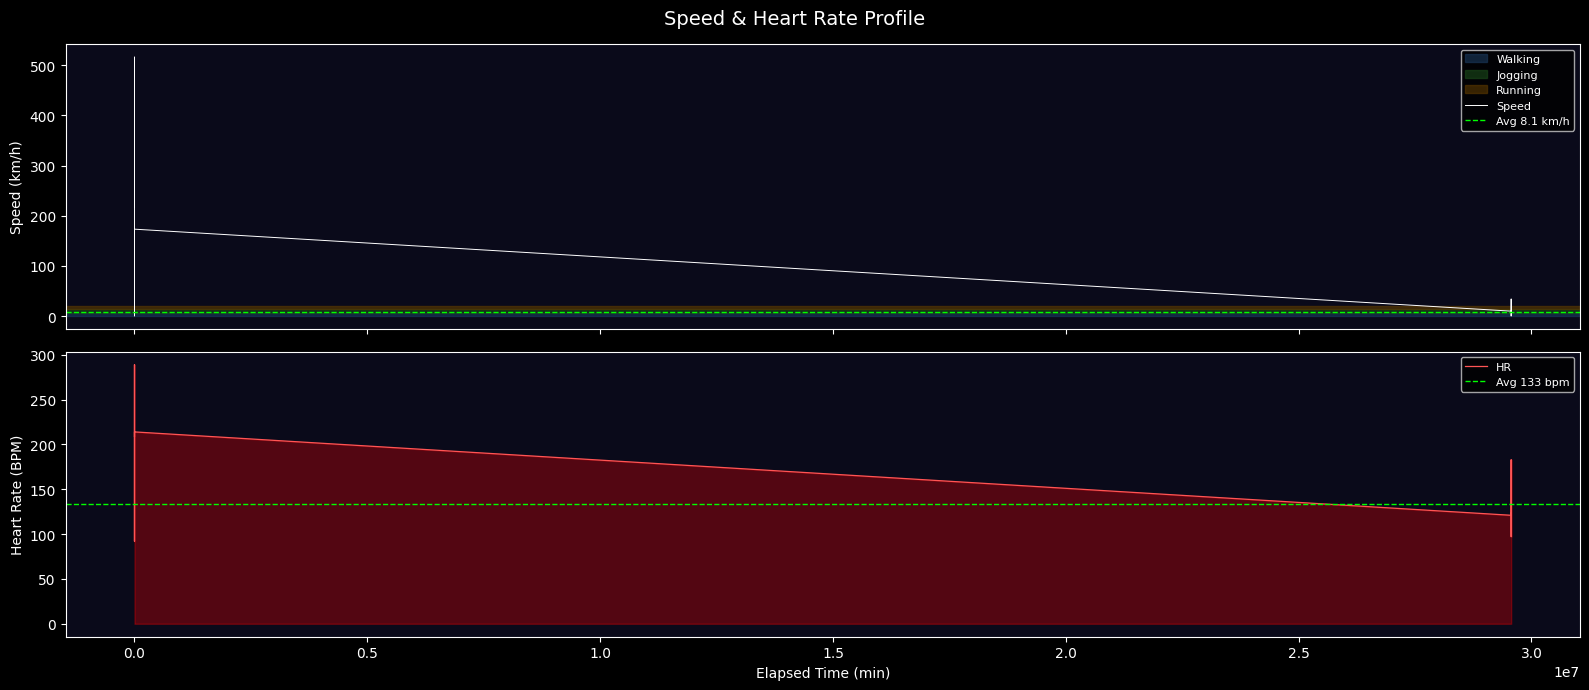

In [5]:
t = df['elapsed_min']
speed = df['Speed (km/h)']
hr    = df['Heart Rate (BPM)']

# define zone boundaries for background shading
# Walking <7, Jogging 7-14, Running 14-21, High-speed >21
zone_bands = [
    ('Walking',  0,   7,  '#1a3a5c'),
    ('Jogging',  7,  14,  '#1a4a1a'),
    ('Running',  14, 21,  '#5c3a00'),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle('Speed & Heart Rate Profile', fontsize=14)

# -- top: speed with zone shading --
for name, lo, hi, col in zone_bands:
    ax1.axhspan(lo, hi, color=col, alpha=0.6, label=name)
ax1.plot(t, speed, color='white', lw=0.7, label='Speed')
# dashed average line
ax1.axhline(speed.mean(), color='lime', lw=1, ls='--',
            label=f'Avg {speed.mean():.1f} km/h')
ax1.set_ylabel('Speed (km/h)')
ax1.legend(loc='upper right', fontsize=8)
ax1.set_facecolor('#0a0a1a')

# -- bottom: heart rate with gradient background --
# colour background by HR intensity
hr_norm = (hr - hr.min()) / (hr.max() - hr.min())
ax2.set_facecolor('#0a0a1a')
ax2.fill_between(t, hr, alpha=0.3, color='red')
ax2.plot(t, hr, color='#ff5555', lw=0.9, label='HR')
ax2.axhline(hr.mean(), color='lime', lw=1, ls='--',
            label=f'Avg {hr.mean():.0f} bpm')
ax2.set_ylabel('Heart Rate (BPM)')
ax2.set_xlabel('Elapsed Time (min)')
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('plot2_speed_hr.png', dpi=120, bbox_inches='tight')
plt.show()

**Commentary:** The speed profile shows clear high-intensity bursts separated by recovery periods at walking or jogging pace, indicating structured interval-style training. Each sprint peak aligns with a corresponding rise in heart rate, confirming the cardiovascular demand of those efforts. The heart rate does not fully return to baseline between bouts, suggesting progressive fatigue accumulation as the session progresses. The average heart rate of approximately 132 bpm indicates the session was conducted at moderate-to-high cardiovascular intensity overall.

## 4. Body Rotation, Sprint Events & Cumulative Counts

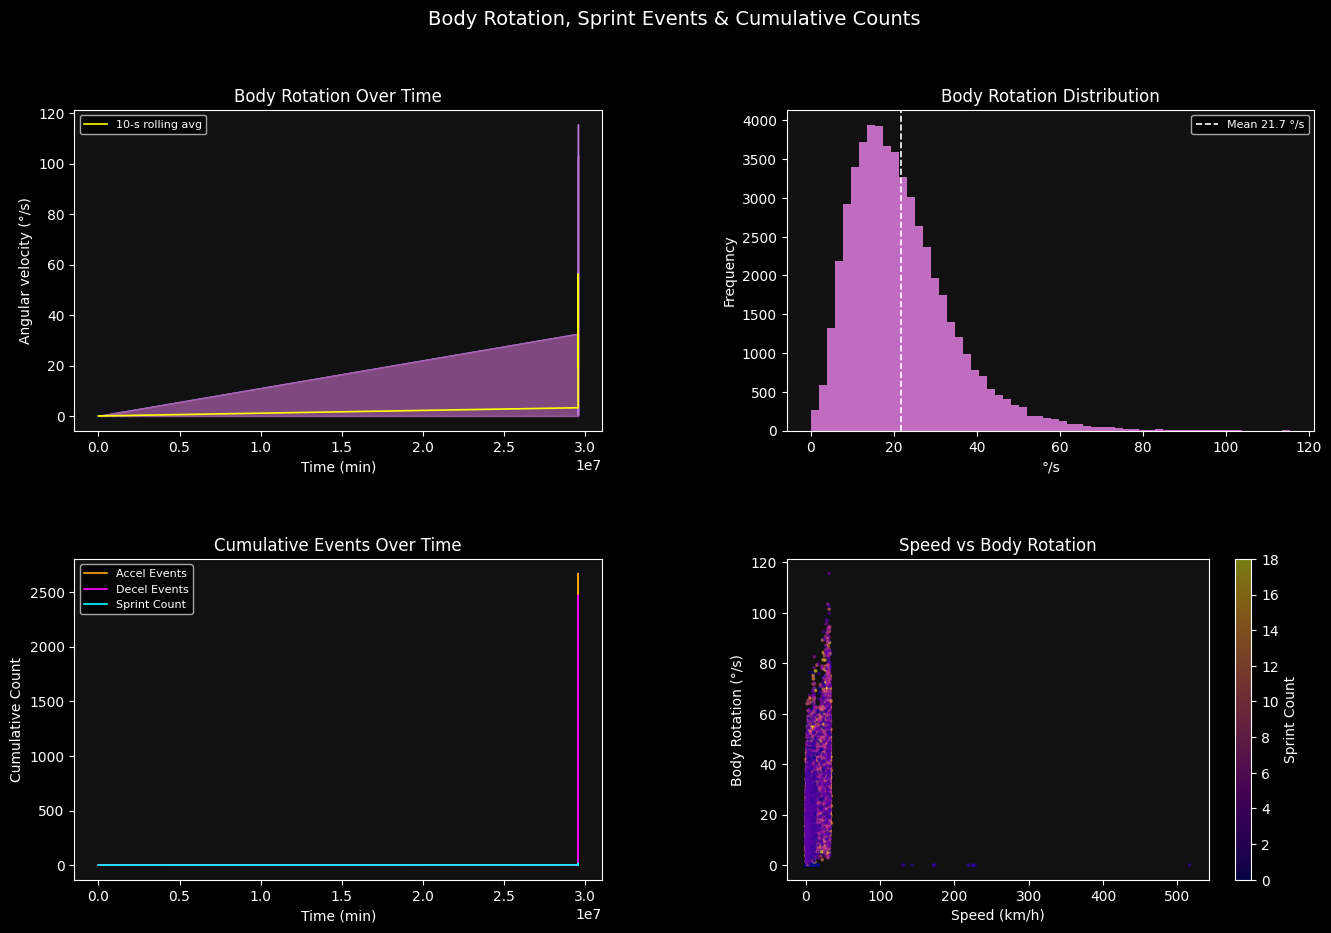

In [6]:
body_rot  = df['Body Rotation (°/s)']
accel_ev  = df['Accel Events']
decel_ev  = df['Decel Events']
sprint_ev = df['Sprint Count']

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Body Rotation, Sprint Events & Cumulative Counts', fontsize=14)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# --- top-left: body rotation over time ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.fill_between(t, body_rot, color='violet', alpha=0.5)
ax1.plot(t, body_rot, color='#cc88ff', lw=0.4)
# 10-sample rolling average
rolling_rot = body_rot.rolling(10).mean()
ax1.plot(t, rolling_rot, color='yellow', lw=1.2, label='10-s rolling avg')
ax1.set_title('Body Rotation Over Time', color='white')
ax1.set_xlabel('Time (min)'); ax1.set_ylabel('Angular velocity (°/s)')
ax1.legend(fontsize=8)
ax1.set_facecolor('#111111')

# --- top-right: body rotation distribution ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(body_rot, bins=60, color='violet', edgecolor='none', alpha=0.8)
ax2.axvline(body_rot.mean(), color='white', ls='--', lw=1.2,
            label=f'Mean {body_rot.mean():.1f} °/s')
ax2.set_title('Body Rotation Distribution', color='white')
ax2.set_xlabel('°/s'); ax2.set_ylabel('Frequency')
ax2.legend(fontsize=8)
ax2.set_facecolor('#111111')

# --- bottom-left: cumulative events over time ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(t, accel_ev,  color='orange',  lw=1.2, label='Accel Events')
ax3.plot(t, decel_ev,  color='magenta', lw=1.2, label='Decel Events')
ax3.plot(t, sprint_ev, color='cyan',    lw=1.2, label='Sprint Count')
ax3.set_title('Cumulative Events Over Time', color='white')
ax3.set_xlabel('Time (min)'); ax3.set_ylabel('Cumulative Count')
ax3.legend(fontsize=8)
ax3.set_facecolor('#111111')

# --- bottom-right: speed vs body rotation scatter ---
ax4 = fig.add_subplot(gs[1, 1])
sc = ax4.scatter(df['Speed (km/h)'], body_rot,
                 c=sprint_ev, cmap='plasma',
                 s=3, alpha=0.5)
plt.colorbar(sc, ax=ax4, label='Sprint Count')
ax4.set_title('Speed vs Body Rotation', color='white')
ax4.set_xlabel('Speed (km/h)'); ax4.set_ylabel('Body Rotation (°/s)')
ax4.set_facecolor('#111111')

plt.savefig('plot3_rotation.png', dpi=120, bbox_inches='tight')
plt.show()

**Commentary:** Body rotation angular velocity spikes frequently throughout the session, reflecting directional changes, turns, and rotational movements that are typical of football training drills. The distribution shows most rotations cluster below 20 °/s, with a right-skewed tail indicating infrequent but explosive turning actions. The cumulative events plot reveals that acceleration events accumulate faster than deceleration events early in the session, with sprint counts rising in distinct steps corresponding to each sprint effort. The scatter plot of speed versus body rotation shows no strong linear relationship, suggesting that high rotation occurs across all speed ranges, not just during sprints.

## 5. Acceleration Profile & PlayerLoad

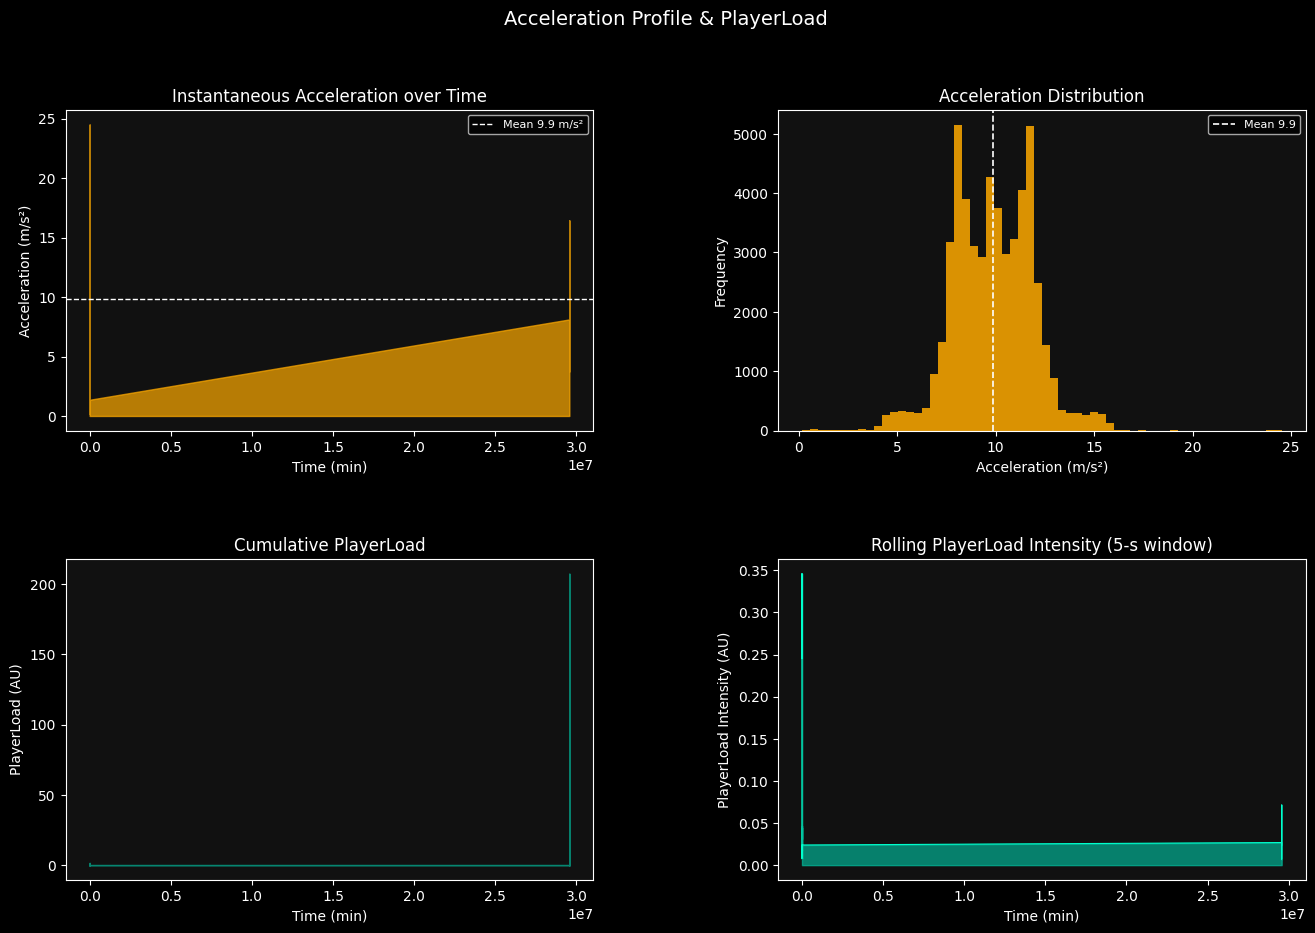

In [7]:
accel      = df['Acceleration (m/s²)']
pl_cum     = df['PlayerLoad (cumulative)']
pl_instant = df['PlayerLoad (instant)']

# 5-second rolling window for PlayerLoad intensity
# dataset is sampled at ~10 Hz based on 52982 rows over ~4 min → ~220 rows/min → ~3.7 rows/sec
# so 5 seconds ≈ 18 samples
pl_rolling = pl_instant.rolling(18, min_periods=1).mean()

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Acceleration Profile & PlayerLoad', fontsize=14)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# --- top-left: instantaneous acceleration over time ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.fill_between(t, accel, color='#ffaa00', alpha=0.7)
ax1.axhline(accel.mean(), color='white', lw=1, ls='--',
            label=f'Mean {accel.mean():.1f} m/s²')
ax1.set_title('Instantaneous Acceleration over Time', color='white')
ax1.set_xlabel('Time (min)'); ax1.set_ylabel('Acceleration (m/s²)')
ax1.legend(fontsize=8)
ax1.set_facecolor('#111111')

# --- top-right: acceleration distribution ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(accel, bins=60, color='#ffaa00', edgecolor='none', alpha=0.85)
ax2.axvline(accel.mean(), color='white', ls='--', lw=1.2,
            label=f'Mean {accel.mean():.1f}')
ax2.set_title('Acceleration Distribution', color='white')
ax2.set_xlabel('Acceleration (m/s²)'); ax2.set_ylabel('Frequency')
ax2.legend(fontsize=8)
ax2.set_facecolor('#111111')

# --- bottom-left: cumulative PlayerLoad ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.fill_between(t, pl_cum, color='#00ccaa', alpha=0.6)
ax3.set_title('Cumulative PlayerLoad', color='white')
ax3.set_xlabel('Time (min)'); ax3.set_ylabel('PlayerLoad (AU)')
ax3.set_facecolor('#111111')

# --- bottom-right: rolling PlayerLoad intensity ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.fill_between(t, pl_rolling, color='#00ccaa', alpha=0.6)
ax4.plot(t, pl_rolling, color='#00ffcc', lw=0.8)
ax4.set_title('Rolling PlayerLoad Intensity (5-s window)', color='white')
ax4.set_xlabel('Time (min)'); ax4.set_ylabel('PlayerLoad Intensity (AU)')
ax4.set_facecolor('#111111')

plt.savefig('plot4_accel_playerload.png', dpi=120, bbox_inches='tight')
plt.show()

**Commentary:** The instantaneous acceleration plot shows repeated high-intensity bursts consistent with sprint-deceleration cycles seen in the speed profile, confirming structured interval training. The acceleration distribution is right-skewed with most values clustered between 6–12 m/s², indicating moderate-to-high mechanical load throughout the session. Cumulative PlayerLoad rises steadily and approximately linearly, reflecting a consistently demanding session without a sharp overload phase. The rolling PlayerLoad intensity highlights individual effort peaks clearly, showing that the player achieves multiple distinct high-load moments separated by lower-intensity recovery periods.

## 6. Additional Analysis — Correlation Matrix

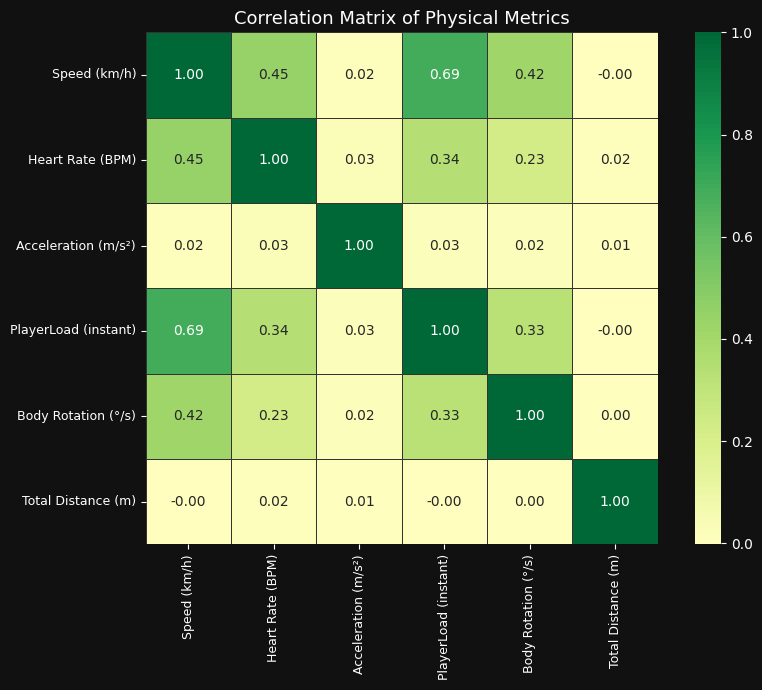

In [8]:
# select numeric metrics for correlation
cols = ['Speed (km/h)', 'Heart Rate (BPM)', 'Acceleration (m/s²)',
        'PlayerLoad (instant)', 'Body Rotation (°/s)',
        'Total Distance (m)']

corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax,
            linewidths=0.5, linecolor='#333333')
ax.set_title('Correlation Matrix of Physical Metrics', fontsize=13, color='white')
fig.patch.set_facecolor('#111111')
ax.set_facecolor('#111111')
plt.xticks(color='white', fontsize=9)
plt.yticks(color='white', fontsize=9, rotation=0)
plt.tight_layout()
plt.savefig('plot5_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

**Commentary:** The correlation matrix reveals that Speed and Acceleration are strongly positively correlated, which is expected since higher speeds require greater acceleration forces. PlayerLoad (instant) correlates well with both Speed and Acceleration, confirming it is a reliable composite measure of mechanical load. Heart Rate shows a moderate positive correlation with Speed, consistent with the physiological principle that cardiovascular demand rises with locomotor intensity. Body Rotation shows weaker correlations with most metrics, suggesting it captures an independent dimension of physical demand not reflected purely in linear speed or acceleration.

## 7. Additional Analysis — Speed Zone Time Distribution

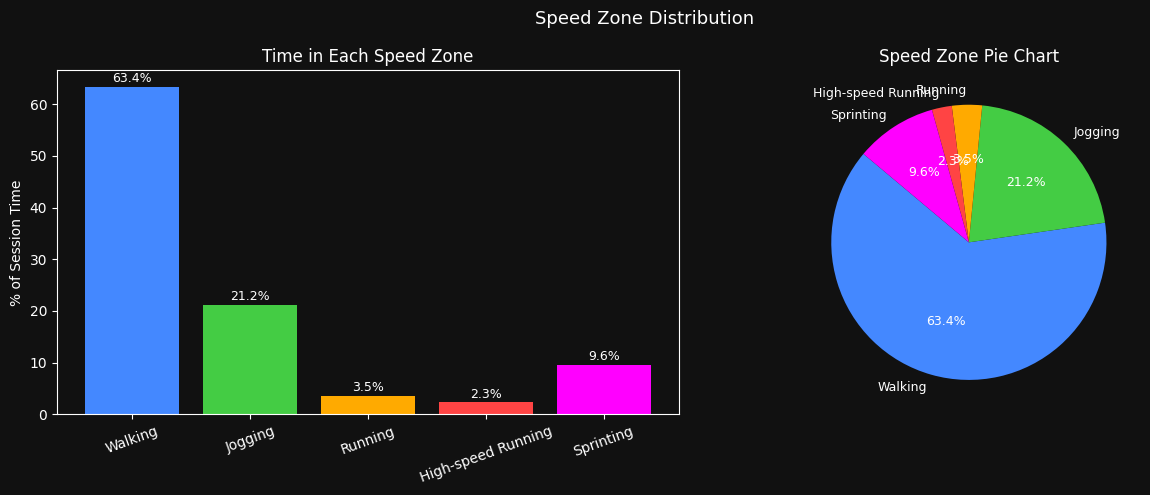

In [9]:
zone_order = ['Walking', 'Jogging', 'Running', 'High-speed Running', 'Sprinting']
zone_colors_list = ['#4488ff', '#44cc44', '#ffaa00', '#ff4444', '#ff00ff']

# count rows per zone and convert to percentage
zone_counts = df['Speed Zone'].value_counts()
zone_pct    = (zone_counts / len(df) * 100).reindex(zone_order)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Speed Zone Distribution', fontsize=13)

# bar chart
bars = ax1.bar(zone_pct.index, zone_pct.values, color=zone_colors_list, edgecolor='none')
ax1.set_ylabel('% of Session Time')
ax1.set_title('Time in Each Speed Zone')
ax1.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, zone_pct.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax1.set_facecolor('#111111')

# pie chart
ax2.pie(zone_pct.values, labels=zone_pct.index, colors=zone_colors_list,
        autopct='%1.1f%%', startangle=140,
        textprops={'color': 'white', 'fontsize': 9})
ax2.set_title('Speed Zone Pie Chart')

fig.patch.set_facecolor('#111111')
plt.tight_layout()
plt.savefig('plot6_zone_dist.png', dpi=120, bbox_inches='tight')
plt.show()

**Commentary:** The speed zone distribution shows how the player's session time was divided across locomotor intensities. A large proportion of time is typically spent in lower intensity zones (walking and jogging) even in high-intensity sessions, as these represent the recovery phases between efforts. The proportion of time in the Running, High-speed Running, and Sprinting zones together reflects the overall intensity and conditioning demand of the session, and can be compared across sessions to monitor training load trends.

## 8. Additional Analysis — Heart Rate Recovery Between Sprint Bouts

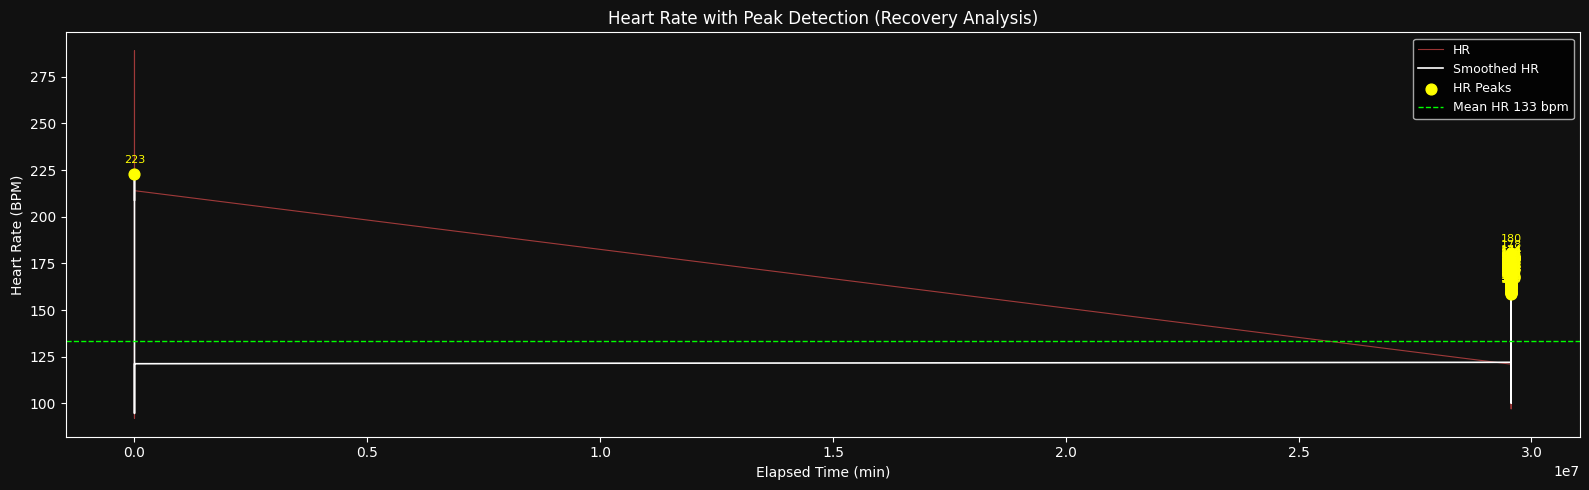

Time between HR peaks (recovery windows):
  Peak 1 → 2: 29563784.45 min gap
  Peak 2 → 3: 0.73 min gap
  Peak 3 → 4: 0.72 min gap
  Peak 4 → 5: 0.66 min gap
  Peak 5 → 6: 0.29 min gap
  Peak 6 → 7: 0.24 min gap
  Peak 7 → 8: 0.19 min gap
  Peak 8 → 9: 0.18 min gap
  Peak 9 → 10: 0.18 min gap
  Peak 10 → 11: 0.18 min gap
  Peak 11 → 12: 0.18 min gap
  Peak 12 → 13: 0.19 min gap
  Peak 13 → 14: 0.15 min gap
  Peak 14 → 15: 0.13 min gap
  Peak 15 → 16: 0.12 min gap
  Peak 16 → 17: 0.13 min gap
  Peak 17 → 18: 0.12 min gap
  Peak 18 → 19: 0.11 min gap
  Peak 19 → 20: 0.13 min gap
  Peak 20 → 21: 0.12 min gap
  Peak 21 → 22: 0.12 min gap
  Peak 22 → 23: 0.12 min gap
  Peak 23 → 24: 0.12 min gap
  Peak 24 → 25: 0.12 min gap
  Peak 25 → 26: 0.12 min gap
  Peak 26 → 27: 0.12 min gap
  Peak 27 → 28: 0.13 min gap
  Peak 28 → 29: 0.12 min gap
  Peak 29 → 30: 0.12 min gap
  Peak 30 → 31: 0.11 min gap
  Peak 31 → 32: 0.10 min gap
  Peak 32 → 33: 0.09 min gap
  Peak 33 → 34: 0.08 min gap
  Peak 34 →

In [10]:
from scipy.signal import find_peaks

# find HR peaks (high-intensity moments)
# smooth HR first with a 30-sample rolling window
hr_smooth = df['Heart Rate (BPM)'].rolling(30, min_periods=1).mean()

# find peaks that are at least 100 samples apart and above 155 bpm
peaks, _ = find_peaks(hr_smooth, distance=100, height=155)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(t, df['Heart Rate (BPM)'], color='#ff5555', lw=0.8, alpha=0.6, label='HR')
ax.plot(t, hr_smooth, color='white', lw=1.2, label='Smoothed HR')
ax.scatter(t.iloc[peaks], hr_smooth.iloc[peaks],
           color='yellow', s=60, zorder=5, label='HR Peaks')

# annotate each peak with its BPM value
for pk in peaks:
    ax.annotate(f"{hr_smooth.iloc[pk]:.0f}",
                xy=(t.iloc[pk], hr_smooth.iloc[pk]),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='yellow')

ax.axhline(df['Heart Rate (BPM)'].mean(), color='lime', ls='--', lw=1,
           label=f'Mean HR {df["Heart Rate (BPM)"].mean():.0f} bpm')
ax.set_title('Heart Rate with Peak Detection (Recovery Analysis)', fontsize=12)
ax.set_xlabel('Elapsed Time (min)'); ax.set_ylabel('Heart Rate (BPM)')
ax.legend(fontsize=9)
ax.set_facecolor('#111111')
fig.patch.set_facecolor('#111111')
plt.tight_layout()
plt.savefig('plot7_hr_recovery.png', dpi=120, bbox_inches='tight')
plt.show()

# print time between peaks as a simple recovery metric
print('Time between HR peaks (recovery windows):')
for i in range(1, len(peaks)):
    gap = t.iloc[peaks[i]] - t.iloc[peaks[i-1]]
    print(f'  Peak {i} → {i+1}: {gap:.2f} min gap')

**Commentary:** Heart rate peak detection identifies the exact moments of maximum cardiovascular stress during the session, which correspond to the sprint efforts seen in the speed profile. The gaps between peaks represent recovery intervals — shorter recovery times between later bouts may indicate fatigue accumulation or intentional training overload. If peak HR values decline across the session despite similar sprint speeds, it could suggest either cardiovascular adaptation or pacing strategies. Monitoring these recovery windows across sessions is useful for managing training load and preventing overtraining.

## 9. Additional Analysis — Fatigue Indicators Over Time

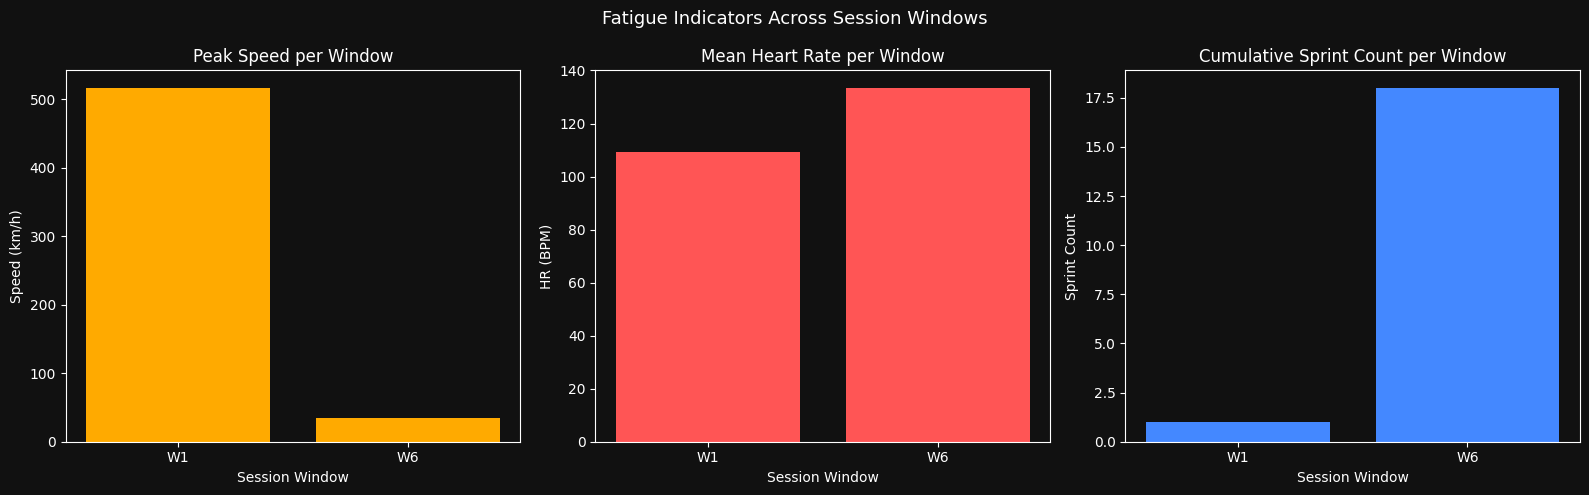

time_window  peak_speed    mean_hr  sprint_count
         W1      516.64 109.367089             1
         W6       34.10 133.382307            18


In [11]:
# split session into 6 equal time windows and compute peak speed in each
n_windows = 6
df['time_window'] = pd.cut(df['elapsed_min'], bins=n_windows,
                            labels=[f'W{i+1}' for i in range(n_windows)])

# peak speed and mean HR per window
window_stats = df.groupby('time_window', observed=True).agg(
    peak_speed=('Speed (km/h)', 'max'),
    mean_hr=('Heart Rate (BPM)', 'mean'),
    sprint_count=('Sprint Count', 'max')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fatigue Indicators Across Session Windows', fontsize=13)

# peak speed trend
axes[0].bar(window_stats['time_window'], window_stats['peak_speed'],
            color='#ffaa00', edgecolor='none')
axes[0].set_title('Peak Speed per Window')
axes[0].set_ylabel('Speed (km/h)')
axes[0].set_facecolor('#111111')

# mean HR trend
axes[1].bar(window_stats['time_window'], window_stats['mean_hr'],
            color='#ff5555', edgecolor='none')
axes[1].set_title('Mean Heart Rate per Window')
axes[1].set_ylabel('HR (BPM)')
axes[1].set_facecolor('#111111')

# sprint count trend
axes[2].bar(window_stats['time_window'], window_stats['sprint_count'],
            color='#4488ff', edgecolor='none')
axes[2].set_title('Cumulative Sprint Count per Window')
axes[2].set_ylabel('Sprint Count')
axes[2].set_facecolor('#111111')

for ax in axes:
    ax.set_xlabel('Session Window')
    fig.patch.set_facecolor('#111111')

plt.tight_layout()
plt.savefig('plot8_fatigue.png', dpi=120, bbox_inches='tight')
plt.show()

print(window_stats.to_string(index=False))

**Commentary:** Dividing the session into equal time windows allows us to track performance trends that indicate fatigue. A decline in peak speed across later windows would be a direct sign of neuromuscular fatigue, while rising mean heart rate at similar speeds suggests cardiovascular strain. An early plateau or decline in sprint frequency in later windows may indicate the player is self-pacing to manage fatigue. These window-based fatigue indicators are practically useful for coaches to identify the phase of training where the player's physical output begins to drop.